## Run original scenario (spinup) - baseline conditions

In [6]:
from os.path import join
import matplotlib.pyplot as plt
from hydromt_sfincs import SfincsModel, utils
from pathlib import Path
import shutil

root_folder  = Path('C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_spinup') 

In [7]:
# Copy and paste the run.bat file in the output folder and put it into each root folder
shutil.copy2(Path('C:/PhD/SFINCS/SFINCS_cloned/output/run.bat'), root_folder / 'run.bat')

# Check 
fn = root_folder / "run.bat"
with open(fn, "r") as f:
    txt = f.read()
print(txt)

call "C:\PhD\SFINCS\SFINCS_cloned\hydromt_sfincs\delta_model\software\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe">sfincs_log.txt



In [8]:
# Run batch file and SFINCS ---------------------------------------------------------
import os

cur_dir = os.getcwd()

run_path = str(root_folder)

# RUN SFINCS --------------------------------------------------------------------------
os.chdir(run_path)
os.system("run.bat")
os.chdir(cur_dir)


In [9]:
# open log file to see if everything ran correctly
fn = os.path.join(run_path, "sfincs_log.txt")

with open(fn, "r") as f:
    txt = f.read()
print(txt)


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.@@...@@.:.:.@@~::::.
     .::~@@@@@@@@@@.....@@@@@@@@@~::.
       ..:~~~~~~~:.......:~~~~~~~:.

In [10]:
# Inspect what filed are in the output folder
path = str(root_folder)
dir_list = os.listdir(path)
print(dir_list)


['figs', 'gis', 'hydromt_sfincs.log', 'run.bat', 'sfincs.20181202.000000.rst', 'sfincs.20181203.000000.rst', 'sfincs.20181204.000000.rst', 'sfincs.20181205.000000.rst', 'sfincs.20181206.000000.rst', 'sfincs.20181207.000000.rst', 'sfincs.20181208.000000.rst', 'sfincs.20181209.000000.rst', 'sfincs.20181210.000000.rst', 'sfincs.20181211.000000.rst', 'sfincs.20181212.000000.rst', 'sfincs.20181213.000000.rst', 'sfincs.20181214.000000.rst', 'sfincs.20181215.000000.rst', 'sfincs.20181216.000000.rst', 'sfincs.20181217.000000.rst', 'sfincs.20181218.000000.rst', 'sfincs.20181219.000000.rst', 'sfincs.20181220.000000.rst', 'sfincs.20181221.000000.rst', 'sfincs.20181222.000000.rst', 'sfincs.20181223.000000.rst', 'sfincs.20181224.000000.rst', 'sfincs.20181225.000000.rst', 'sfincs.20181226.000000.rst', 'sfincs.20181227.000000.rst', 'sfincs.20181228.000000.rst', 'sfincs.20181229.000000.rst', 'sfincs.20181230.000000.rst', 'sfincs.20181231.000000.rst', 'sfincs.dep', 'sfincs.dis', 'sfincs.ind', 'sfincs.i

## RUN OTHER SCENARIOS

#### 100 yr RP River Discharge

2026-01-31 14:37:03,496 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-31 14:37:03,541 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-01-31 14:37:03,542 - hydromt.model.model - model - WARNING - No region component found in components.
2026-01-31 14:37:03,839 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-01-31 14:37:03,840 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-01-31 14:37:03,842 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: scs
2026-01-31 14:37:03,844 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-01-31 14:37:06,484 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-01-31 14:37:06,485 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-01-31 14:37:06,

(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'SFINCS waterlevel forcing (bzs)'}, ylabel='waterlevel\n[m+ref]'>,
        <Axes: title={'center': 'SFINCS discharge forcing (dis)'}, ylabel='discharge\n[m3.s-1]'>],
       dtype=object))

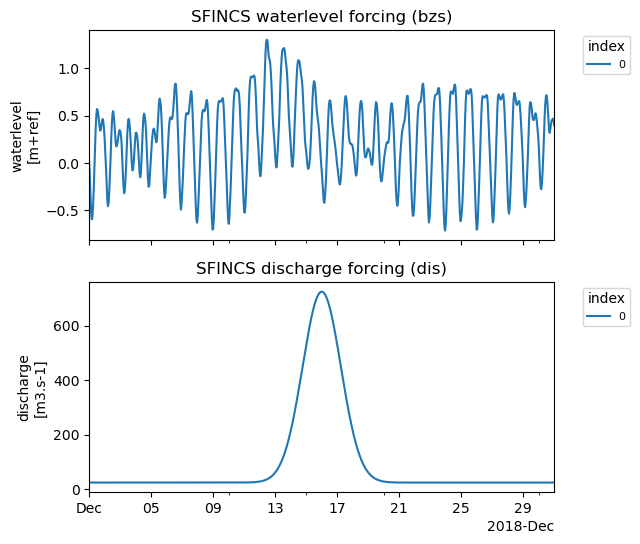

In [12]:
from hydromt._utils import log
import pandas as pd
from hydromt_sfincs import SfincsModel
from datetime import datetime
from pathlib import Path

root_folder = Path('C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_spinup')

sf = SfincsModel(
    data_libs= ["data_catalog_v1.yml"],  # specify which data libraries to use
    root= root_folder,  # specify the root directory for the model
    mode="r"  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite)
)
sf.read()

# change the root and mode to write the updated model to a new location
new_root = Path('C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_100RD')

sf.root.set(new_root, mode="w+")

sf.config.update(
    {
        "rstfile": "C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_spinup/sfincs.20181209.000000.rst"
    }
)

# # Initial conditions component - function (water levels along coast) 
# # https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.components.grid.SfincsInitialConditions.create.html
# sf.initial_conditions.create(
#  ini = x,    # use water levels of spinup 
# )

combined_dataset = pd.read_excel("C:\\PhD\\SFINCS\\SFINCS_cloned\\input\\Combined_dataset_global_deltas.xlsx")
sf.discharge_points.create_timeseries(
    index = [0],
    shape = "gaussian",
    offset = combined_dataset.loc[combined_dataset['BasinID2'] == 620947, 'Discharge_dist'].values[0],
    peak = 700,
    tpeak = 15 * 86400,
    duration = 7 * 86400,
    timestep = 600
)

sf.write()

sf.plot_forcing()

In [13]:
# Run the model 
import shutil

# Copy and paste the run.bat file in the output folder and put it into each root folder
shutil.copy2(Path('C:/PhD/SFINCS/SFINCS_cloned/output/run.bat'), new_root / 'run.bat')

# Check 
fn = new_root / "run.bat"
with open(fn, "r") as f:
    txt = f.read()
print(txt)

# Run batch file and SFINCS ---------------------------------------------------------
import os
cur_dir = os.getcwd()
run_path = str(new_root)

# RUN SFINCS --------------------------------------------------------------------------
os.chdir(run_path)
os.system("run.bat")
os.chdir(cur_dir)

# open log file to see if everything ran correctly
fn = os.path.join(run_path, "sfincs_log.txt")

with open(fn, "r") as f:
    txt = f.read()
print(txt)

# Inspect what files are in the output folder
path = str(new_root)
dir_list = os.listdir(path)
print(dir_list)

call "C:\PhD\SFINCS\SFINCS_cloned\hydromt_sfincs\delta_model\software\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe">sfincs_log.txt


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@

#### 100 yr RP Storm Surge

2026-01-31 14:56:08,583 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-31 14:56:08,624 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-01-31 14:56:08,625 - hydromt.model.model - model - WARNING - No region component found in components.
2026-01-31 14:56:08,876 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-01-31 14:56:08,878 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-01-31 14:56:08,880 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: scs
2026-01-31 14:56:08,881 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-01-31 14:56:11,199 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-01-31 14:56:11,200 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-01-31 14:56:11,

(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'SFINCS waterlevel forcing (bzs)'}, ylabel='waterlevel\n[m+ref]'>,
        <Axes: title={'center': 'SFINCS discharge forcing (dis)'}, ylabel='discharge\n[m3.s-1]'>],
       dtype=object))

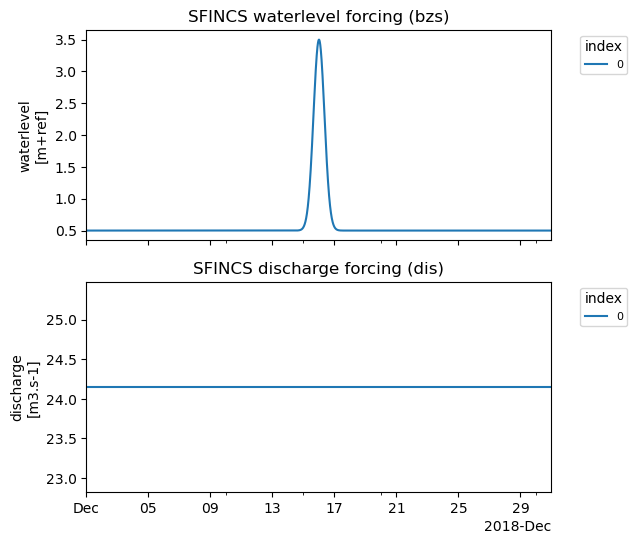

In [14]:
from hydromt._utils import log
import pandas as pd
from hydromt_sfincs import SfincsModel
from datetime import datetime
from pathlib import Path

root_folder = Path('C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_spinup')

sf = SfincsModel(
    data_libs= ["data_catalog_v1.yml"],  # specify which data libraries to use
    root= root_folder,  # specify the root directory for the model
    mode="r"  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite)
)
sf.read()

# change the root and mode to write the updated model to a new location
new_root = Path('C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_100SS')

sf.root.set(new_root, mode="w+")

sf.config.update(
    {
        "rstfile": "C:/PhD/SFINCS/SFINCS_cloned/output/sfincs_620947_spinup/sfincs.20181209.000000.rst"
    }
)

# # Initial conditions component - function (water levels along coast) 
# # https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.components.grid.SfincsInitialConditions.create.html
# sf.initial_conditions.create(
#  ini = x,    # use water levels of spinup 
# )

# Manually create timeseries forcing - using GTSMS for 100-yr RP
sf.water_level.create_timeseries(
    shape = "gaussian", 
    timestep = 600, # 10 minutes in seconds
    offset = 0.5,
    peak = 3, # based on GTSM data previously used 
    tpeak = 15 * 86400,
    duration = 2 * 86400,
)

sf.write()

sf.plot_forcing()

In [15]:
# Run the model 
import shutil

# Copy and paste the run.bat file in the output folder and put it into each root folder
shutil.copy2(Path('C:/PhD/SFINCS/SFINCS_cloned/output/run.bat'), new_root / 'run.bat')

# Check 
fn = new_root / "run.bat"
with open(fn, "r") as f:
    txt = f.read()
print(txt)

# Run batch file and SFINCS ---------------------------------------------------------
import os
cur_dir = os.getcwd()
run_path = str(new_root)

# RUN SFINCS --------------------------------------------------------------------------
os.chdir(run_path)
os.system("run.bat")
os.chdir(cur_dir)

# open log file to see if everything ran correctly
fn = os.path.join(run_path, "sfincs_log.txt")

with open(fn, "r") as f:
    txt = f.read()
print(txt)

# Inspect what files are in the output folder
path = str(new_root)
dir_list = os.listdir(path)
print(dir_list)

call "C:\PhD\SFINCS\SFINCS_cloned\hydromt_sfincs\delta_model\software\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe">sfincs_log.txt


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@